In [2]:
from __future__ import print_function
from fenics import *
from mshr import *
from dolfin import *
import time
import matplotlib.pyplot as plt
import numpy as np
import functools
import copy
import inspect
import pandas as pd
import os
import psutil
import tracemalloc

# Problem statement

A ring with radii $R_1 = 0.8$ and $R_2 = 1$ is formed by two equal halves and centered at the origin. One half as an electrical conductivity of 1 S/m, while the other has a conductivity of D. A horizontal dipole source is injecting direct current at position $(0,0.9)$. The ring is insulated. The electrical potential satisfies the diffusion equation:
$$-\nabla\cdot(\sigma(x,y)\nabla u) = f$$
$$f =  e^{-100((x-x_0+h)^2+(y-y_0)^2)} -  e^{-100((x-x_0-h)^2+(y-y_0)^2)}$$
The conductivity obeys the following distribution:
$$\sigma(x,y) = \begin{cases}
1,\text{ y<0}\\
D,\text{ y>0}
\end{cases}$$
Where D can be 1, 10, or 100 S/m.

Boundary conditions:
$$\partial_n u = 0$$
on $\Gamma$.


# Obtaining a weak form

$$-\nabla\cdot(\sigma(x,y)\nabla u) = f$$
let's muliply the equation by the test function v and integrate over the domain
$$-\int_S v\nabla\cdot(\sigma(x,y)\nabla u) dS= \int_S vf dS$$
Using Gauss-Ostrogradskiy theorem we can obtain
$$\int_S v\nabla\cdot(\sigma(x,y)\nabla u) dS = \int_S \nabla\cdot (v \sigma(x,y)\nabla u) dS - \int_S \sigma(x,y)\nabla u \cdot \nabla v dS = \int_\Gamma (v \sigma(x,y)\nabla u)\cdot n d\Gamma - \int_S \sigma(x,y)\nabla u \cdot \nabla v dS$$
the first term is equal to zero because of boundary conditions. Thus, we obtain the weak form of the equation
$$\int_S \sigma(x,y)\nabla u \cdot \nabla v dS = \int_S vf dS$$

# Compatibility condition

To proof that compatibility condition is satisfied we need to show that the equations $-\nabla\cdot(\sigma(x,y)\nabla u) = f$ and $\partial_n u = 0$ have common solution.
Let's integrate the first one over the domain $\Omega$.

$$- \int_\Omega \nabla\cdot(\sigma(x,y)\nabla u) d\Omega = \int_\Omega f d\Omega $$
Using Gauss-Ostrogradskiy theorem
$$- \int_\Gamma \sigma(x,y)\nabla u\cdot n d\Gamma = \int_\Omega f d\Omega $$
On the other hand from boundary condition we have
$$ \int_\Gamma \nabla u\cdot n d\Gamma = 0$$
Let's consider the half of the domain ($y>0$), here $sigma(x,y)$ is a constant. So we need to proof only that $\int_\Omega f d\Omega =0$. Similarly with another half.
So we need to proof that
$$\int_{\Omega_{y>0}} e^{-100((x-x_0+h)^2+(y-y_0)^2)} d\Omega= \int_{\Omega_{y>0}} e^{-100((x-x_0-h)^2+(y-y_0)^2)}d\Omega$$
The source term is antisymmetric about the line $x = 0$. Verification with $x_0 = 0$ explicitly substituted:
$$f(-x) = \int_\Omega e^{-100((-x+h)^2+(y-y_0)^2)} - \int_\Omega e^{-100((-x-h)^2+(y-y_0)^2)} = \int_\Omega e^{-100((x-h)^2+(y-y_0)^2)} - \int_\Omega e^{-100((x+h)^2+(y-y_0)^2)} = -f(x)$$
Thus we have integral of the antysymmetric function over the symmetryc domain, it will be equal to zero.

# Solution

## classes and functions

In [7]:
class UpperHalf(SubDomain):
    def inside(self, x, on_boundary):
        return x[1]>=0+DOLFIN_EPS
class LowerHalf(SubDomain):
    def inside(self, x, on_boundary):
        return x[1]<=0-DOLFIN_EPS

In [8]:
class sigma(UserExpression):
    def __init__(self, subdomains, d0, d1):
        super().__init__()
        self.subdomains = subdomains
        self.d0 = d0
        self.d1 = d1
    def eval_cell(self, values, x, cell):
        values[0] = self.d0+(self.d1-self.d0)*self.subdomains[cell.index]
    def value_shape(self):
        return ()

In [9]:
def boundary(x, on_boundary):
    return on_boundary

In [10]:
#create a function with memory profiling capability
def solve_eq(solvers, solver, a, b, u):
    return solve(a == b, u) if solver == 'default' else solvers[solver].solve(a, u, b)

In [11]:
innerCircle = Circle(Point(0, 0), 0.8)
outerCircle = Circle(Point(0, 0), 1)
annulus = outerCircle - innerCircle
#init halves
Upper = UpperHalf()
Lower = LowerHalf()

In [12]:
def getSolver(solverName):
    if solverName == 'default':
        return None
    else:
        solver_, precond = solverName.split('-')
        solver = PETScKrylovSolver(solver_, precond)
        solver_parameters = solver.parameters
        solver_parameters["error_on_nonconvergence"] = False
        solver_parameters["maximum_iterations"] = 1000
        return solver

In [13]:
def tabulateData(solvers, Ds, meshsizes):
    data = {'time': {meshsize: {D: {solver: None for solver in solvers} for D in Ds} for meshsize in meshsizes},
          'itercount': {meshsize: {D: {solver: None for solver in solvers} for D in Ds} for meshsize in meshsizes},
          'vector': {meshsize: {D: {solver: None for solver in solvers} for D in Ds} for meshsize in meshsizes},
            'memory': {meshsize: {D: {solver: None for solver in solvers} for D in Ds} for meshsize in meshsizes},
          }
    for meshsize in meshsizes:
        print(meshsize)
        mesh = generate_mesh(annulus, meshsize)
        domains = MeshFunction("size_t", mesh, mesh.topology().dim())
        domains.set_all(0)
        Upper.mark(domains, 0)
        Lower.mark(domains, 1)
        V = FunctionSpace(mesh, 'P', 1)
        f = Expression("exp(-100*(pow(x[0]+0.1,2)+pow(x[1]-0.9,2)))-exp(-100*(pow(x[0]-0.1,2)+pow(x[1]-0.9,2)))", degree=2)
        for D_ in Ds:
            D = sigma(domains, D_, 1)
            for solver_ in solvers:
                mem_before = process_memory()
                u = TrialFunction(V)
                v = TestFunction(V)
                a = (D*inner(grad(u), grad(v)))*dx
                L = f*v*dx
                LHS, RHS = assemble_system(a, L)
                u = Function(V)
                solver = getSolver(solver_)
                if solver is None:
                    t0 = time.perf_counter()
                    solve(a==L, u)
                    t = time.perf_counter()-t0
                    mem_after = process_memory()
                    # mem_after = tracemalloc.get_traced_memory()
                    data['time'][meshsize][D_][solver_] = t
                    data['itercount'][meshsize][D_][solver_] = 1
                    data['vector'][meshsize][D_][solver_] = copy.deepcopy(u.vector().get_local())
                    data['memory'][meshsize][D_][solver_] = mem_after - mem_before
                    # del u, v, a, L, LHS, RHS
                else:
                    u_ = u.vector()
                    nsBasis = Vector(u_) #create a vector object from petsc vector
                    V.dofmap().set(nsBasis, 1)
                    nsBasis/=nsBasis.norm('l2')
                    nsBasis_ = VectorSpaceBasis([nsBasis])
                    as_backend_type(LHS).set_nullspace(nsBasis_)
                    nsBasis_.orthogonalize(RHS)
                    t0 = time.perf_counter()
                    iters = solver.solve(LHS, u_, RHS)
                    t = time.perf_counter() - t0
                    mem_after = process_memory()
                    data['time'][meshsize][D_][solver_] = t
                    data['itercount'][meshsize][D_][solver_] = iters
                    data['vector'][meshsize][D_][solver_] = copy.deepcopy(u_.get_local())
                    data['memory'][meshsize][D_][solver_] = mem_after - mem_before
    return data

In [14]:
def process_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss

In [30]:
data = tabulateData(
    ['default', 'cg-sor', 'cg-icc', 'cg-hypre_amg'],
    [1],
    [10, 35, 115]
)

10
Solving linear variational problem.
35
Solving linear variational problem.
115
Solving linear variational problem.


## Mesh

Number of vertices in mesh 1: 150


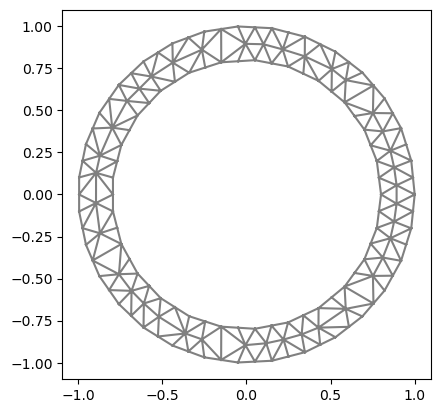

In [10]:
mesh1 = generate_mesh(annulus, 10)
plot(mesh1)
print("Number of vertices in mesh 1:", mesh1.num_vertices())

Number of vertices in mesh 2: 1026


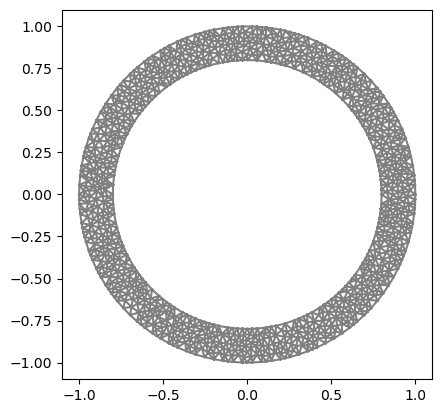

In [11]:
mesh2 = generate_mesh(annulus, 35)
plot(mesh2)
print("Number of vertices in mesh 2:", mesh2.num_vertices())

Number of vertices in mesh 3: 10089


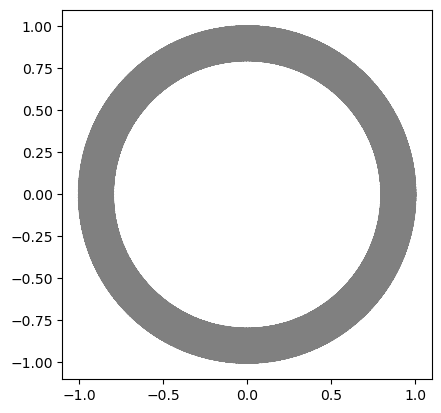

In [12]:
mesh3 = generate_mesh(annulus, 115)
plot(mesh3)
print("Number of vertices in mesh 3:", mesh3.num_vertices())

## Results

In [33]:
arrays = [np.array(["default", "default", "default", "cg-sor", "cg-sor", "cg-sor", "cg-icc", "cg-icc", "cg-icc", 
                    "cg-hypre_amg", "cg-hypre_amg", "cg-hypre_amg"]),
          np.array([150,1026,10089, 150,1026,10089, 150,1026,10089, 150,1026,10089])]
table = pd.DataFrame(columns = ['CPU time', 'iteration count', 'memory usage'], index = arrays)
table['CPU time'] = [0.01136, 0.04372, 0.37836, 0.00022, 0.00284, 0.25732, 
                     0.00018, 0.00164,  0.26301, 0.00051, 0.00373, 0.09948]
table['iteration count'] = [1, 1, 1, 30, 86, 272, 28, 64, 220, 5,6,7]
table['memory usage'] = [6422528, 7208960, 13369344, 5373952, 5505024, 6029312, 5505024, 5373952, 6160384, 6684672,6946816, 9043968]
table

CPU time  iteration count  memory usage
default      150     0.01136                1       6422528
             1026    0.04372                1       7208960
             10089   0.37836                1      13369344
cg-sor       150     0.00022               30       5373952
             1026    0.00284               86       5505024
             10089   0.25732              272       6029312
cg-icc       150     0.00018               28       5505024
             1026    0.00164               64       5373952
             10089   0.26301              220       6160384
cg-hypre_amg 150     0.00051                5       6684672
             1026    0.00373                6       6946816
             10089   0.09948                7       9043968

The larger the grid size, the greater the program's running time and memory usage. Direct method (LU-factorisation, here - default) is less admissible then iterative solvers because it is more computational complex ($n^3$), it requires more memory usage (to store entire matrices L and U).

The fastest solver for large matrixes is the conjugate gradient method with multigrid preconditioner because of its optimal complexity. But it requires more memory then the conjugate gradient method with SOR preconditioner or with Icomplete Choleskiy factorisation.

Object cannot be plotted directly, projecting to piecewise linears.


Text(0.5, 1.0, 'Induced currents')

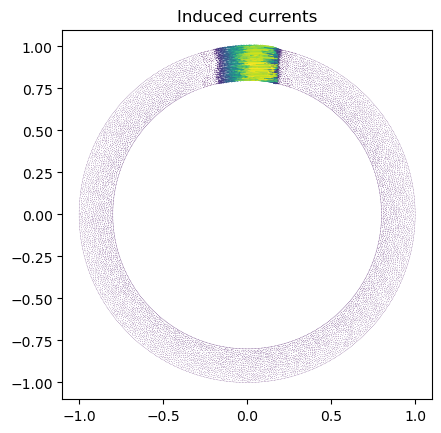

In [34]:
d = data['vector'][115][1]['cg-icc']
mesh = generate_mesh(annulus, 115)

V = FunctionSpace(mesh, 'P', 1)
u = Function(V)
u.vector().set_local(d)

domains = MeshFunction("size_t", mesh, mesh.topology().dim())
domains.set_all(0)
Upper.mark(domains, 0)#not necessary
Lower.mark(domains, 1)
D = sigma(domains, 1, 1)
plot(-D*grad(u))
plt.title('Induced currents')

Text(0.5, 1.0, 'Solution')

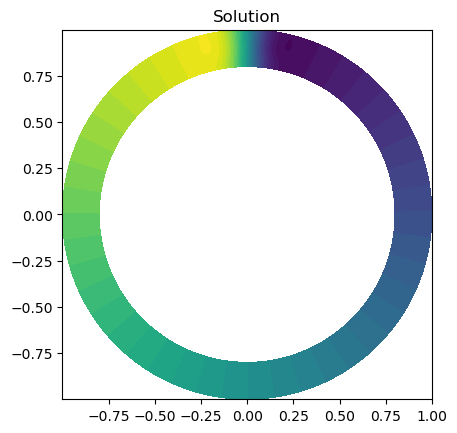

In [35]:
plot(u)
plt.title('Solution')

# Solution for differend D

In [15]:
data = tabulateData(
    ['default', 'cg-sor', 'cg-icc', 'cg-hypre_amg'],
    [1, 10, 100, 1000],
    [115]
)

115
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.


In [15]:
arrays = [np.array(["default", "default", "default", "default","cg-sor", "cg-sor", "cg-sor","cg-sor", "cg-icc", "cg-icc", "cg-icc","cg-icc", 
                    "cg-hypre_amg", "cg-hypre_amg", "cg-hypre_amg", "cg-hypre_amg"]),
          np.array([1,10,100, 1000,1,10,100, 1000,1,10,100, 1000,1,10,100, 1000])]
table = pd.DataFrame(columns = ['CPU time', 'iteration count', 'memory usage'], index = arrays)
table['CPU time'] = [0.763, 0.822, 0.862, 0.892, 0.156, 0.144, 
                     0.158, 0.144,  0.141,0.118, 0.245, 0.125, 0.067, 0.069, 0.064, 0.062]
table['iteration count'] = [1, 1, 1,1, 272, 270, 273, 269, 220, 204, 222,217,7,7,7,7]
table['memory usage'] = [12058624, 12189696, 12320768, 12058624, 
                         4980736, 5111808, 5242880, 5898240, 
                         5373952, 5242880,5373952, 5242880,
                         7995392, 7995392, 7733248, 7995392
                        ]
table

CPU time  iteration count  memory usage
default      1        0.763                1      12058624
             10       0.822                1      12189696
             100      0.862                1      12320768
             1000     0.892                1      12058624
cg-sor       1        0.156              272       4980736
             10       0.144              270       5111808
             100      0.158              273       5242880
             1000     0.144              269       5898240
cg-icc       1        0.141              220       5373952
             10       0.118              204       5242880
             100      0.245              222       5373952
             1000     0.125              217       5242880
cg-hypre_amg 1        0.067                7       7995392
             10       0.069                7       7995392
             100      0.064                7       7733248
             1000     0.062                7       7995392

the conjugate gradient method with multigrid preconditioner is still the fastest algorithm. There is almost no difference between the execution time, iterations and memory usage while changing the parameter D. 

In [16]:
d1 = data['vector'][115][1]['cg-icc']
d10 = data['vector'][115][10]['cg-icc']
d100 = data['vector'][115][100]['cg-icc']
d1000 = data['vector'][115][1000]['cg-icc']

In [17]:
mesh = generate_mesh(annulus, 115)

Text(0.5, 1.0, 'Folution for D = 1')

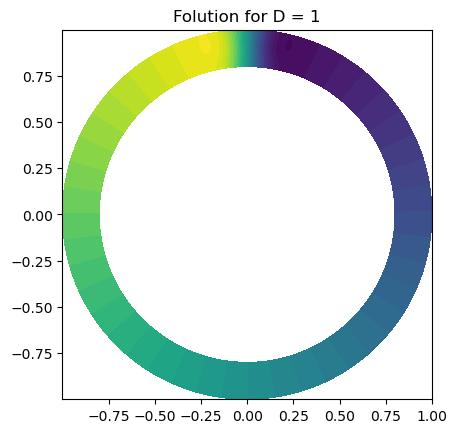

In [18]:
V = FunctionSpace(mesh, 'P', 1)
u = Function(V)
u.vector().set_local(d1)
plot(u)
plt.title('Solution for D = 1')

Object cannot be plotted directly, projecting to piecewise linears.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Text(0.5, 1.0, 'induced currents for D = 1')

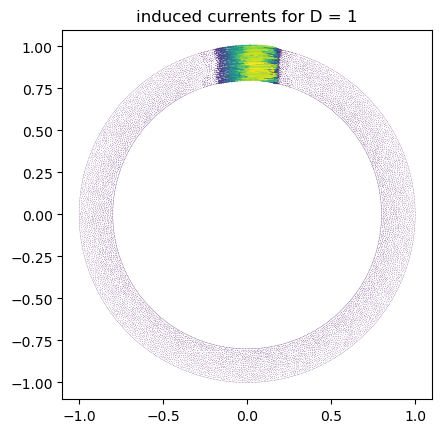

In [19]:
domains = MeshFunction("size_t", mesh, mesh.topology().dim())
domains.set_all(0)
Upper.mark(domains, 0)#not necessary
Lower.mark(domains, 1)
D = sigma(domains, 1, 1)
plot(-D*grad(u))
plt.title("induced currents for D = 1")

Text(0.5, 1.0, 'Solution for D = 10')

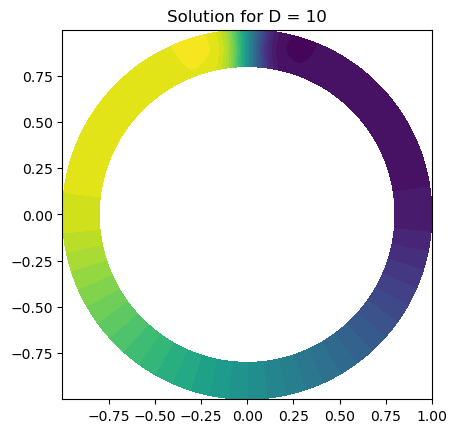

In [23]:
V = FunctionSpace(mesh, 'P', 1)
u = Function(V)
u.vector().set_local(d10)
plot(u)
plt.title('Solution for D = 10')

Object cannot be plotted directly, projecting to piecewise linears.


Text(0.5, 1.0, 'induced currents for D = 10')

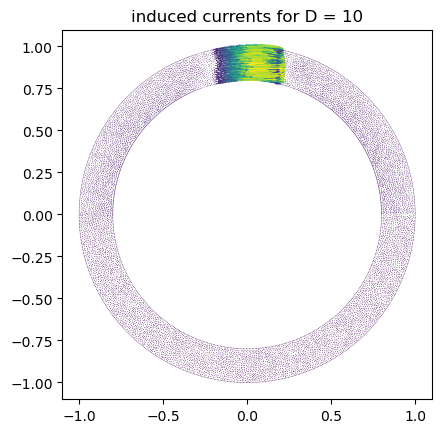

In [20]:
domains = MeshFunction("size_t", mesh, mesh.topology().dim())
domains.set_all(0)
Upper.mark(domains, 0)#not necessary
Lower.mark(domains, 1)
D = sigma(domains, 10, 1)
plot(-D*grad(u))
plt.title("induced currents for D = 10")

Text(0.5, 1.0, 'Solution for D = 100')

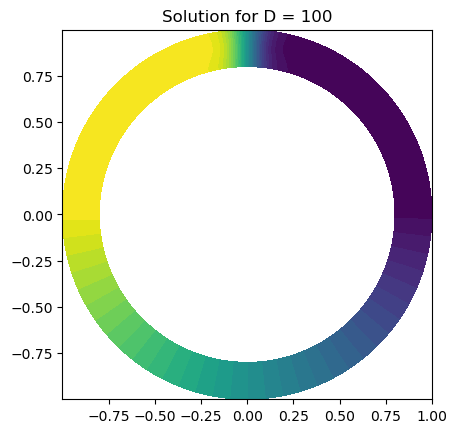

In [24]:
V = FunctionSpace(mesh, 'P', 1)
u = Function(V)
u.vector().set_local(d100)
plot(u)
plt.title('Solution for D = 100')

Object cannot be plotted directly, projecting to piecewise linears.


Text(0.5, 1.0, 'induced currents for D = 100')

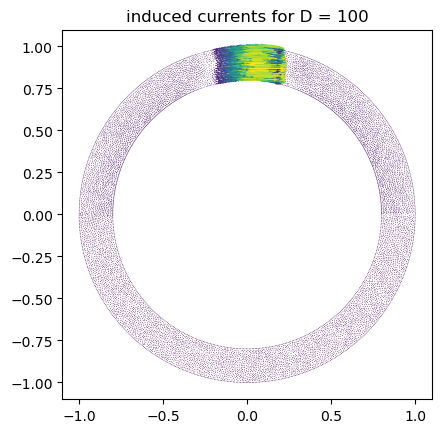

In [21]:
domains = MeshFunction("size_t", mesh, mesh.topology().dim())
domains.set_all(0)
Upper.mark(domains, 0)#not necessary
Lower.mark(domains, 1)
D = sigma(domains, 100, 1)
plot(-D*grad(u))
plt.title("induced currents for D = 100")

Text(0.5, 1.0, 'Solution for D = 1000')

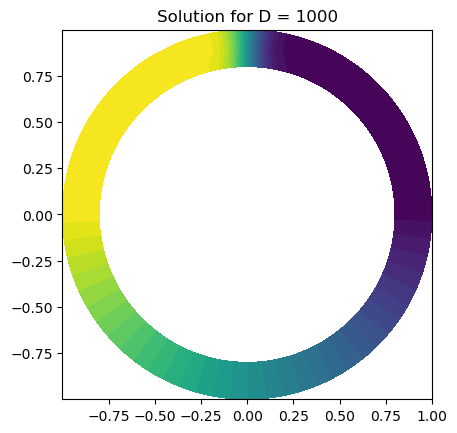

In [25]:
V = FunctionSpace(mesh, 'P', 1)
u = Function(V)
u.vector().set_local(d1000)
plot(u)
plt.title('Solution for D = 1000')

Object cannot be plotted directly, projecting to piecewise linears.


Text(0.5, 1.0, 'induced currents for D = 1000')

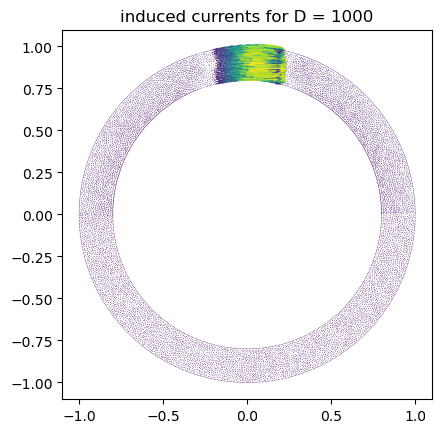

In [22]:
domains = MeshFunction("size_t", mesh, mesh.topology().dim())
domains.set_all(0)
Upper.mark(domains, 0)#not necessary
Lower.mark(domains, 1)
D = sigma(domains, 1000, 1)
plot(-D*grad(u))
plt.title("induced currents for D = 1000")